In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('india_housing_prices.csv')

# 1. Missing values & duplicates (dataset has none, but kept for pipeline robustness)
df = df.drop_duplicates(subset='ID').reset_index(drop=True)
df = df.dropna().reset_index(drop=True)  # no-op here, but safe for future data refreshes

In [2]:
# 2. Feature engineering: Amenity count + infrastructure proxy scores
df['Amenity_Count'] = df['Amenities'].str.split(', ').apply(len)

transport_map = {'Low': 0.0, 'Medium': 0.5, 'High': 1.0}
df['Transport_Score'] = df['Public_Transport_Accessibility'].map(transport_map)
df['Security_Score'] = df['Security'].map({'No': 0, 'Yes': 1})
df['Parking_Score'] = df['Parking_Space'].map({'No': 0, 'Yes': 1})

In [4]:
# 3. Composite Appreciation Potential Score (fully data-driven, see methodology above)

def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

city_avg_price = df.groupby('City')['Price_per_SqFt'].transform('mean')
loc_index = minmax(city_avg_price)
infra_index = (minmax(df['Nearby_Schools']) + minmax(df['Nearby_Hospitals'])
               + df['Transport_Score'] + df['Security_Score']) / 4
amenity_index = df['Amenity_Count'] / df['Amenity_Count'].max()
age_index = 1 - minmax(df['Age_of_Property'])

df['Appreciation_Score'] = (0.30 * loc_index + 0.30 * infra_index + 0.20 * amenity_index + 0.20 * age_index)

In [5]:
# 4. Target creation

# CAGR range 4%-9% cited from Indian residential real estate appreciation reports (NHB / Knight Frank)

MIN_CAGR, MAX_CAGR = 0.04, 0.09
df['Implied_CAGR'] = MIN_CAGR + df['Appreciation_Score'] * (MAX_CAGR - MIN_CAGR)
df['Future_Price_5Y'] = df['Price_in_Lakhs'] * (1 + df['Implied_CAGR']) ** 5

df['Good_Investment'] = (df['Appreciation_Score'] > df['Appreciation_Score'].median()).astype(int)

In [6]:
# 5. Additional engineered features (Price per Sqft already exists in file, keep as-is)

df['Price_per_SqFt_calc'] = df['Price_in_Lakhs'] * 100000 / df['Size_in_SqFt']  # sanity-check vs given col
df['Floor_Ratio'] = df['Floor_No'] / df['Total_Floors'].replace(0, 1)

In [7]:
# 6. Encoding categorical features

from sklearn.preprocessing import LabelEncoder, StandardScaler

categorical_cols = ['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status',
                     'Facing', 'Owner_Type', 'Availability_Status']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    label_encoders[col] = le  # keep for inverse_transform / Streamlit form later

In [8]:
# 7. Scaling numerical features (fit only on training data in Step 3 — placeholder here for column list)

numeric_cols = ['BHK', 'Size_in_SqFt', 'Price_per_SqFt', 'Year_Built', 'Floor_No',
                 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals',
                 'Amenity_Count', 'Floor_Ratio']
# Scaling is done AFTER train/test split in Step 3 to avoid data leakage — see there.

In [9]:
# 8. Save cleaned dataset

df.to_csv('india_housing_prices_cleaned.csv', index=False)
print(df.shape)
print(df[['Price_in_Lakhs','Appreciation_Score','Implied_CAGR','Future_Price_5Y','Good_Investment']].head())

(250000, 41)
   Price_in_Lakhs  Appreciation_Score  Implied_CAGR  Future_Price_5Y  \
0          489.76            0.561953      0.068098       680.829094   
1          195.52            0.700328      0.075016       280.715674   
2          183.79            0.413796      0.060690       246.753812   
3          300.29            0.530161      0.066508       414.344461   
4          182.90            0.525502      0.066275       252.092553   

   Good_Investment  
0                1  
1                1  
2                0  
3                1  
4                1  


# Exploratory Data Analysis (EDA)

In [33]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('india_housing_prices_cleaned.csv')

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = "crest"
ACCENT = "#2E5C8A"
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.labelsize": 11, "axes.edgecolor": "#444444",
})

# Q1–Q5: Price & Size Analysis

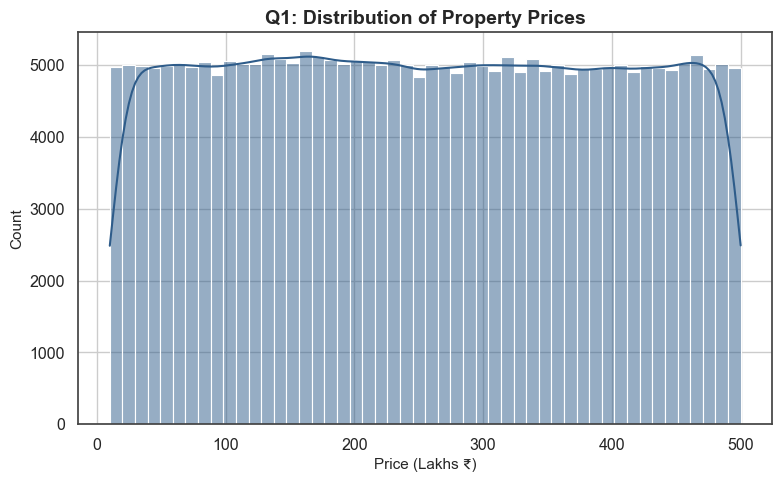

In [35]:
# Q1: Distribution of property prices

plt.figure(figsize=(8,5))
sns.histplot(df['Price_in_Lakhs'], bins=50, kde=True, color=ACCENT)
plt.title("Q1: Distribution of Property Prices")
plt.xlabel("Price (Lakhs ₹)")
plt.tight_layout()
plt.show()

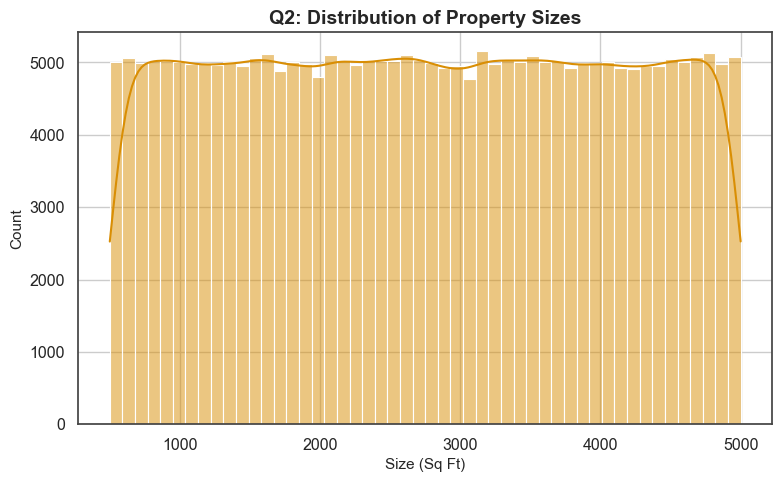

In [37]:
# Q2: Distribution of property sizes

plt.figure(figsize=(8,5))
sns.histplot(df['Size_in_SqFt'], bins=50, kde=True, color="#D98E04")
plt.title("Q2: Distribution of Property Sizes")
plt.xlabel("Size (Sq Ft)")
plt.tight_layout()
plt.show()

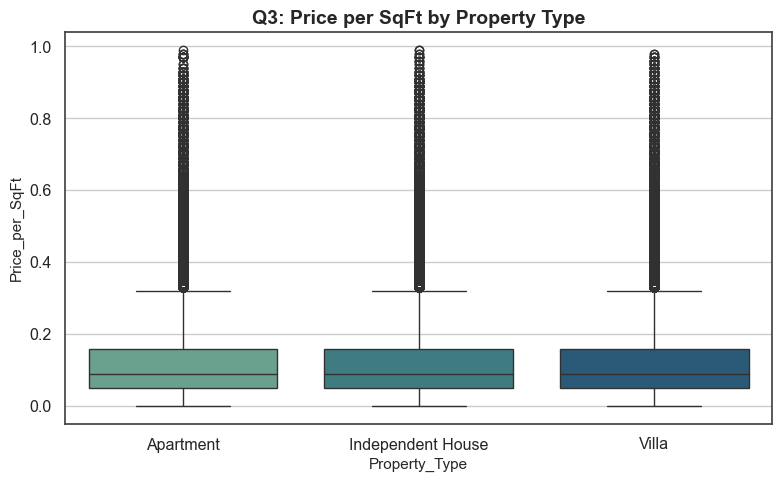

In [38]:
# Q3: Price per sqft by property type

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Property_Type', y='Price_per_SqFt', hue='Property_Type', palette=PALETTE, legend=False)
plt.title("Q3: Price per SqFt by Property Type")
plt.tight_layout()
plt.show()

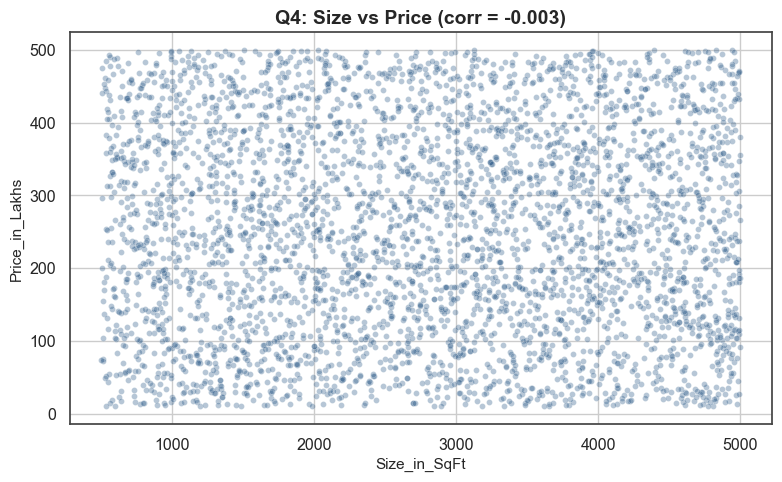

Q4 correlation: -0.0025


In [39]:
# Q4: Relationship between size and price

plt.figure(figsize=(8,5))
sample = df.sample(4000, random_state=42)
sns.scatterplot(data=sample, x='Size_in_SqFt', y='Price_in_Lakhs', alpha=0.35, color=ACCENT, s=18)
corr_size_price = df['Size_in_SqFt'].corr(df['Price_in_Lakhs'])
plt.title(f"Q4: Size vs Price (corr = {corr_size_price:.3f})")
plt.tight_layout()
plt.show()
print(f"Q4 correlation: {corr_size_price:.4f}")

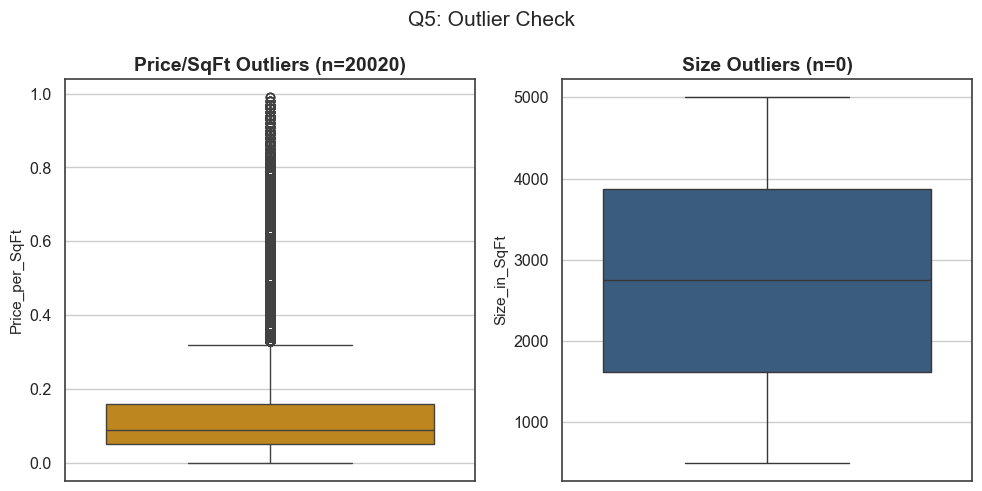

In [40]:
# Q5: Outliers in price per sqft / size (IQR method)

def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return series[(series < lower) | (series > upper)]

ppsf_outliers = iqr_outliers(df['Price_per_SqFt'])
size_outliers = iqr_outliers(df['Size_in_SqFt'])

fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.boxplot(y=df['Price_per_SqFt'], color="#D98E04", ax=axes[0])
axes[0].set_title(f"Price/SqFt Outliers (n={len(ppsf_outliers)})")
sns.boxplot(y=df['Size_in_SqFt'], color=ACCENT, ax=axes[1])
axes[1].set_title(f"Size Outliers (n={len(size_outliers)})")
plt.suptitle("Q5: Outlier Check")
plt.tight_layout()
plt.show()

# Q6–Q10: Location-based Analysis

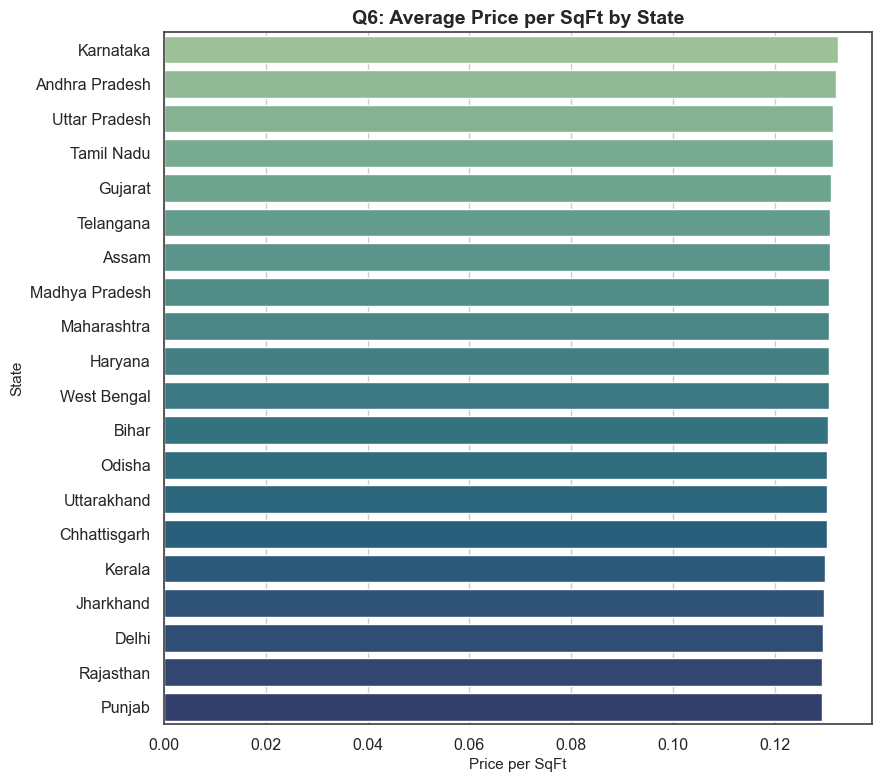

In [41]:
# Q6: Avg price per sqft by state

plt.figure(figsize=(9,8))
state_ppsf = df.groupby('State')['Price_per_SqFt'].mean().sort_values(ascending=False)
sns.barplot(x=state_ppsf.values, y=state_ppsf.index, hue=state_ppsf.index, palette=PALETTE, legend=False)
plt.title("Q6: Average Price per SqFt by State")
plt.xlabel("Price per SqFt")
plt.tight_layout()
plt.show()

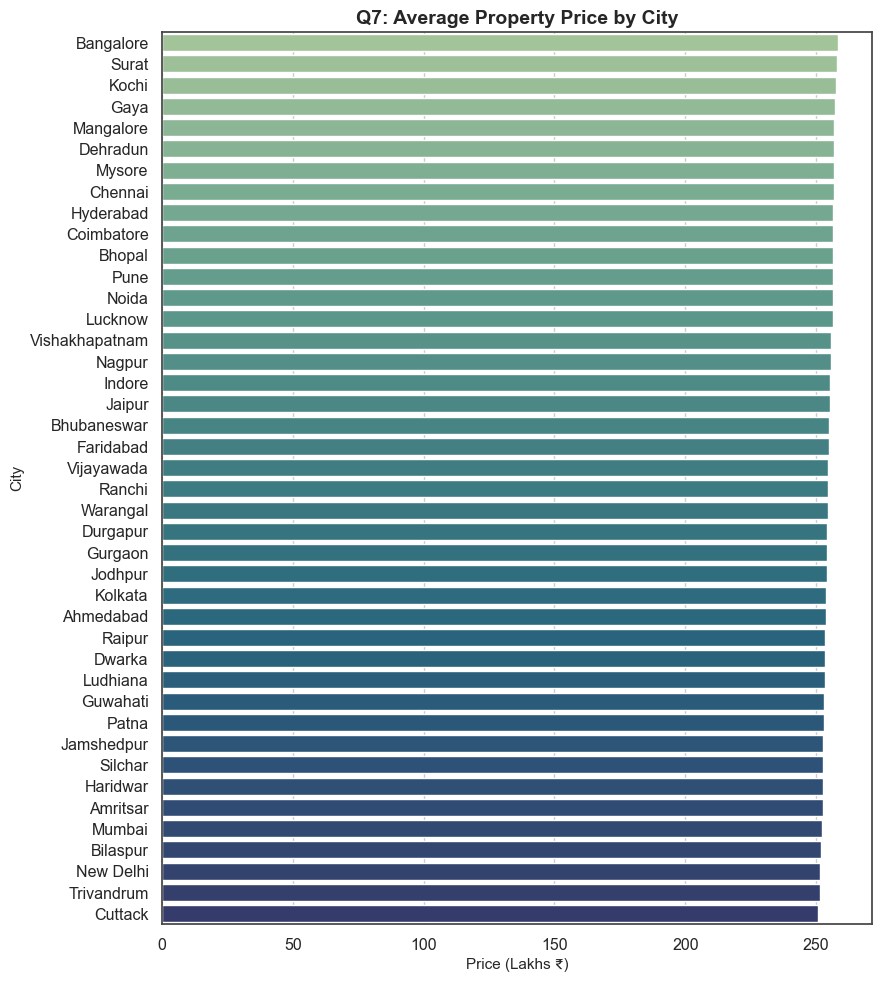

In [42]:
# Q7: Avg property price by city

plt.figure(figsize=(9,10))
city_price = df.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False)
sns.barplot(x=city_price.values, y=city_price.index, hue=city_price.index, palette=PALETTE, legend=False)
plt.title("Q7: Average Property Price by City")
plt.xlabel("Price (Lakhs ₹)")
plt.tight_layout()
plt.show()

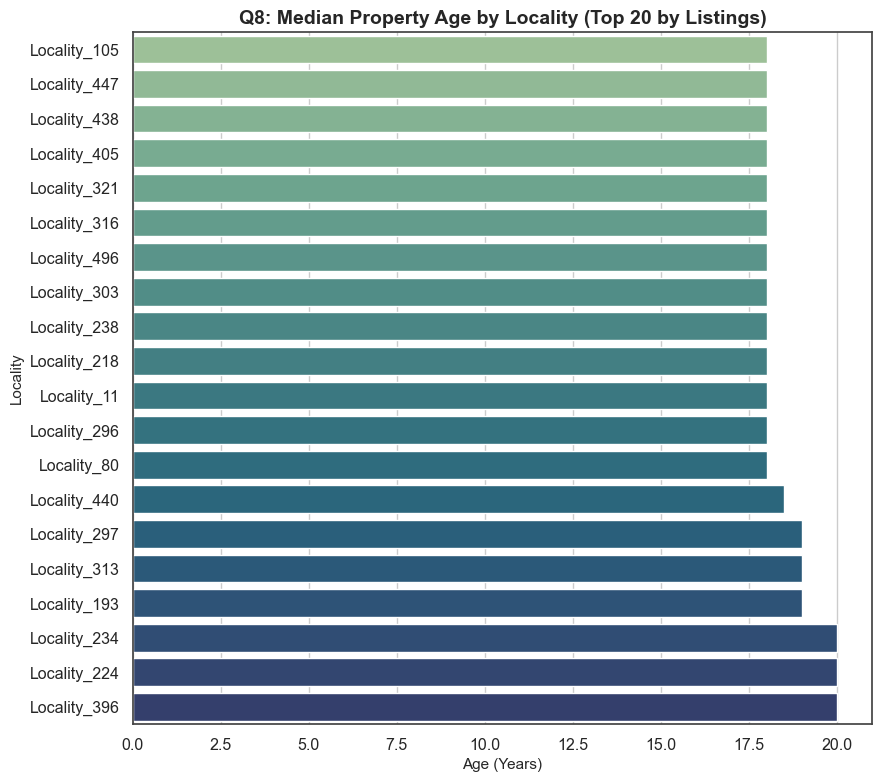

In [43]:
# Q8: Median age of properties by locality (top 20 by count for readability)

plt.figure(figsize=(9,8))
top_localities = df['Locality'].value_counts().head(20).index
loc_age = df[df['Locality'].isin(top_localities)].groupby('Locality')['Age_of_Property'].median().sort_values()
sns.barplot(x=loc_age.values, y=loc_age.index, hue=loc_age.index, palette=PALETTE, legend=False)
plt.title("Q8: Median Property Age by Locality (Top 20 by Listings)")
plt.xlabel("Age (Years)")
plt.tight_layout()
plt.show()

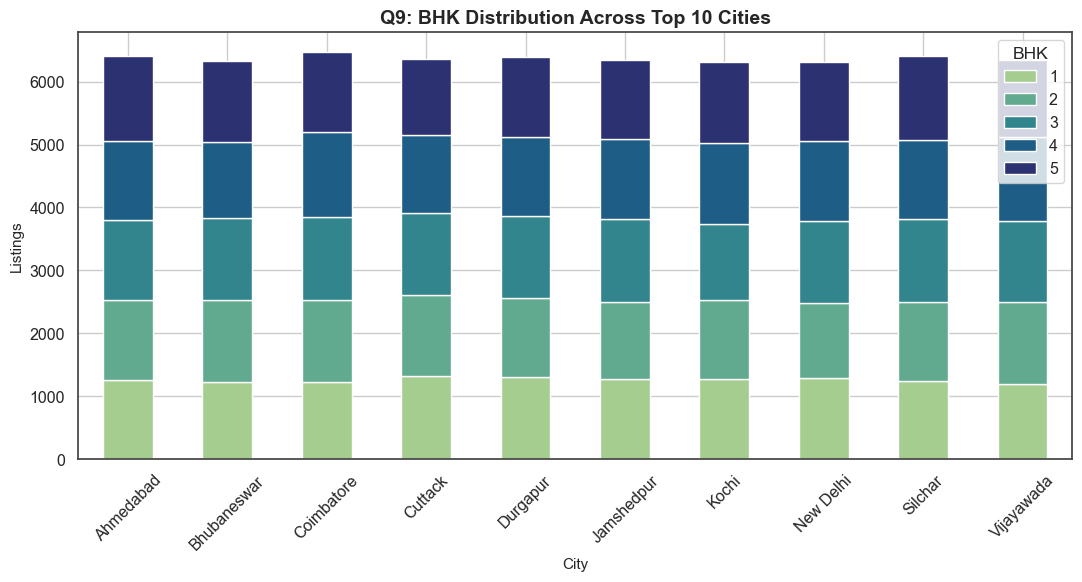

In [44]:
# Q9: BHK distribution across cities (top 10 cities by count)

plt.figure(figsize=(11,6))
top_cities = df['City'].value_counts().head(10).index
bhk_city = df[df['City'].isin(top_cities)].groupby(['City','BHK']).size().unstack(fill_value=0)
bhk_city.plot(kind='bar', stacked=True, colormap='crest', ax=plt.gca())
plt.title("Q9: BHK Distribution Across Top 10 Cities")
plt.ylabel("Listings")
plt.xticks(rotation=45)
plt.legend(title="BHK")
plt.tight_layout()
plt.show()

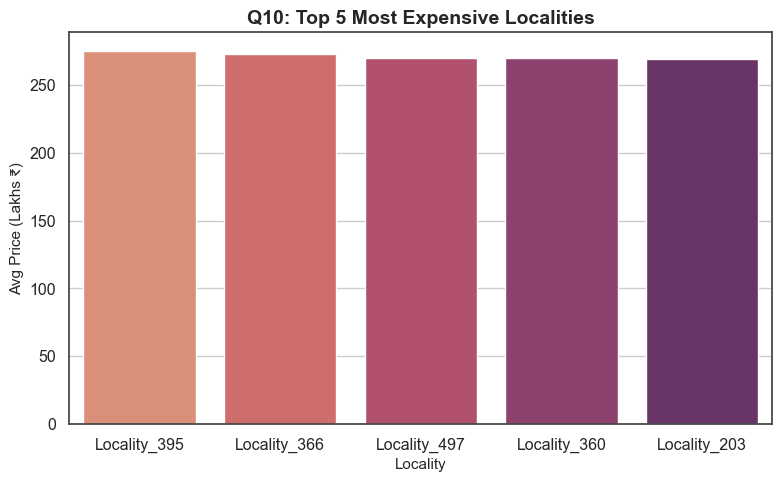

Locality
Locality_395    275.425987
Locality_366    273.411996
Locality_497    269.995540
Locality_360    269.806792
Locality_203    269.033716
Name: Price_in_Lakhs, dtype: float64


In [45]:
# Q10: Price trends for top 5 most expensive localities

plt.figure(figsize=(8,5))
top5_expensive = df.groupby('Locality')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(5)
sns.barplot(x=top5_expensive.index, y=top5_expensive.values, hue=top5_expensive.index, palette="flare", legend=False)
plt.title("Q10: Top 5 Most Expensive Localities")
plt.ylabel("Avg Price (Lakhs ₹)")
plt.tight_layout()
plt.show()
print(top5_expensive)

# Q11–Q15: Feature Relationship & Correlation

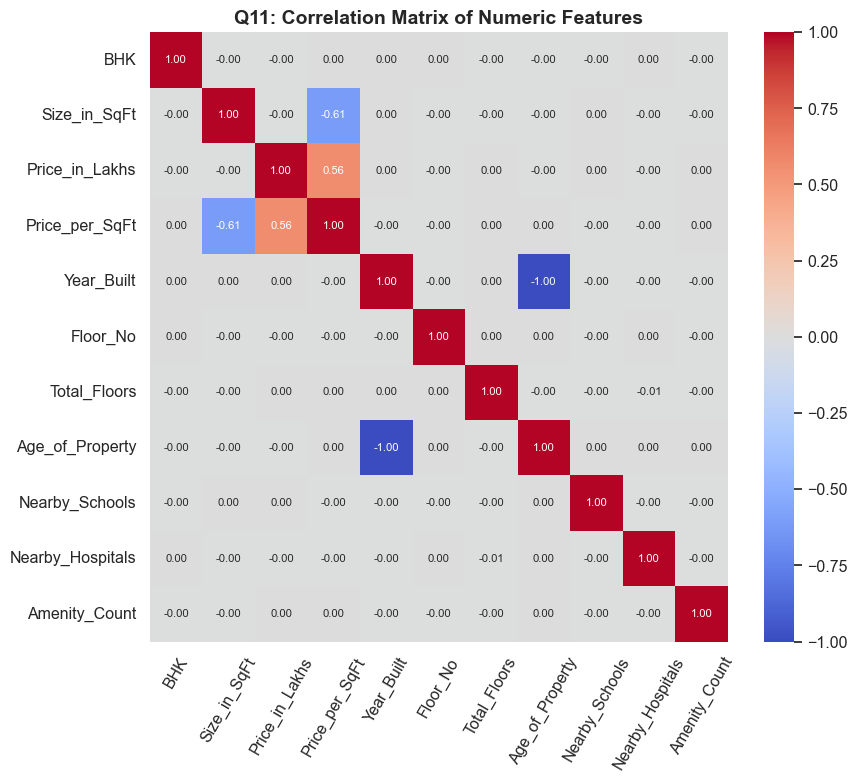

In [46]:
# Q11: Numeric feature correlations

plt.figure(figsize=(9,8))
numeric_cols = ['BHK','Size_in_SqFt','Price_in_Lakhs','Price_per_SqFt','Year_Built',
                 'Floor_No','Total_Floors','Age_of_Property','Nearby_Schools',
                 'Nearby_Hospitals','Amenity_Count']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={"size": 8})
plt.title("Q11: Correlation Matrix of Numeric Features")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

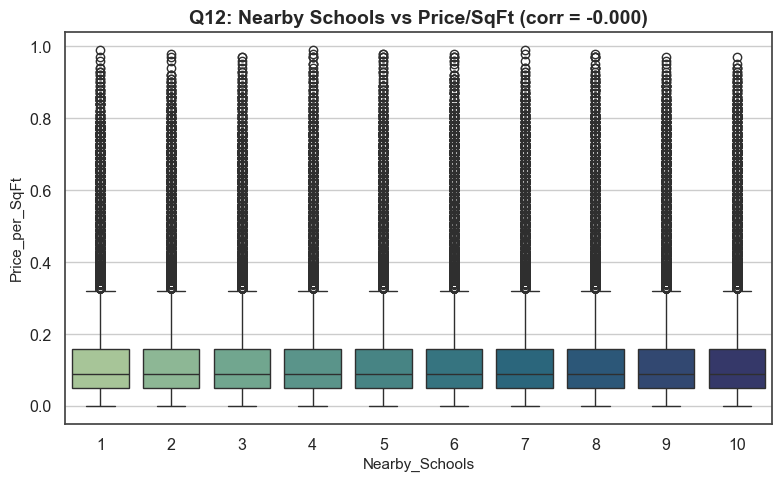

In [47]:
# Q12: Nearby schools vs price per sqft

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Nearby_Schools', y='Price_per_SqFt', hue='Nearby_Schools', palette=PALETTE, legend=False)
c12 = df['Nearby_Schools'].corr(df['Price_per_SqFt'])
plt.title(f"Q12: Nearby Schools vs Price/SqFt (corr = {c12:.3f})")
plt.tight_layout()
plt.show()

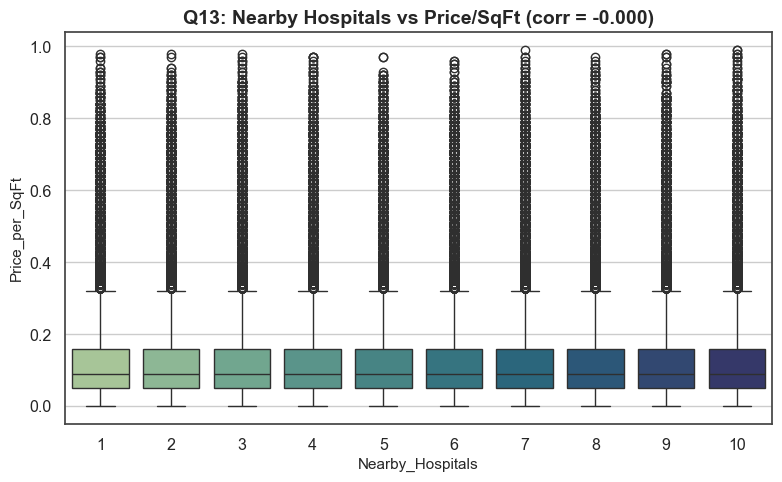

In [48]:
# Q13: Nearby hospitals vs price per sqft

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Nearby_Hospitals', y='Price_per_SqFt', hue='Nearby_Hospitals', palette=PALETTE, legend=False)
c13 = df['Nearby_Hospitals'].corr(df['Price_per_SqFt'])
plt.title(f"Q13: Nearby Hospitals vs Price/SqFt (corr = {c13:.3f})")
plt.tight_layout()
plt.show()

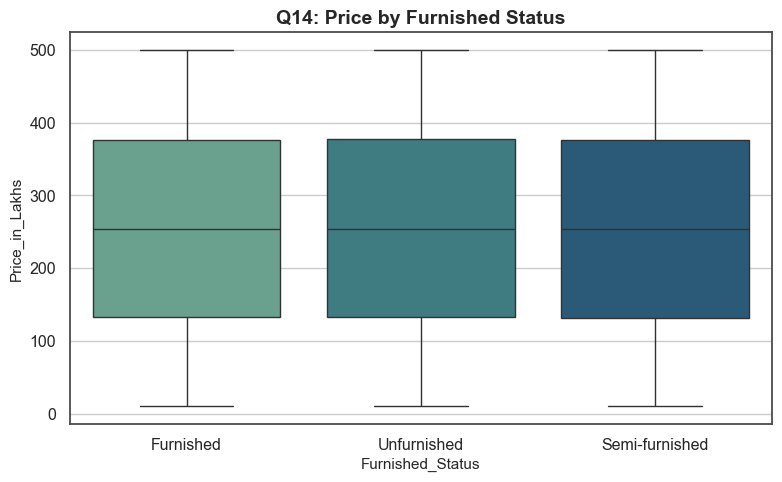

In [49]:
# Q14: Price by furnished status

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Furnished_Status', y='Price_in_Lakhs', hue='Furnished_Status', palette=PALETTE, legend=False)
plt.title("Q14: Price by Furnished Status")
plt.tight_layout()
plt.show()

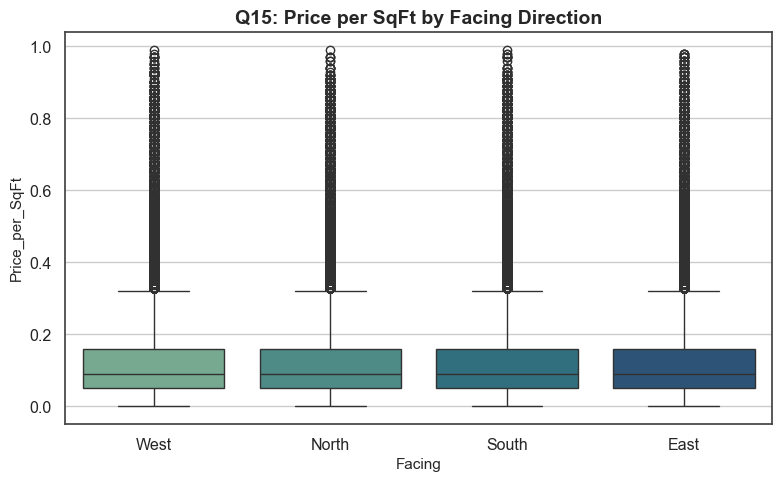

In [50]:
# Q15: Price per sqft by facing direction

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Facing', y='Price_per_SqFt', hue='Facing', palette=PALETTE, legend=False)
plt.title("Q15: Price per SqFt by Facing Direction")
plt.tight_layout()
plt.show()

# Q16–Q20: Investment / Amenities / Ownership Analysis

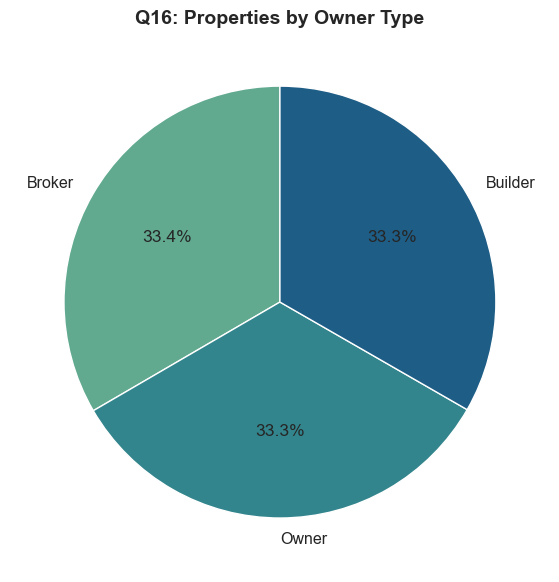

In [56]:
# Q16: Properties by owner type

plt.figure(figsize=(6,6))
owner_counts = df['Owner_Type'].value_counts()
plt.pie(owner_counts.values, labels=owner_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette(PALETTE, len(owner_counts)), startangle=90)
plt.title("Q16: Properties by Owner Type")
plt.tight_layout()
plt.show()

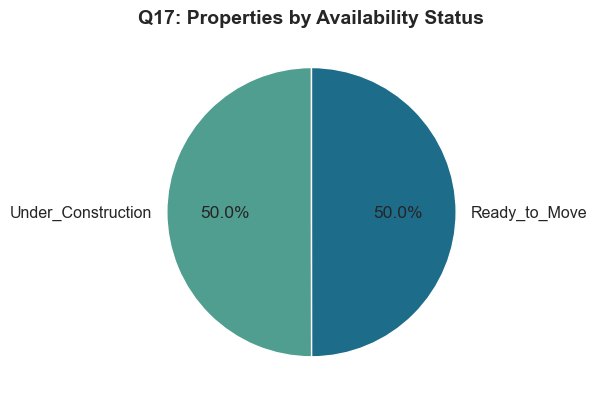

In [57]:
# Q17: Properties by availability status

plt.figure(figsize=(6,6))
avail_counts = df['Availability_Status'].value_counts()
plt.pie(avail_counts.values, labels=avail_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette(PALETTE, len(avail_counts)), startangle=90)
plt.title("Q17: Properties by Availability Status")
plt.tight_layout()
plt.show()

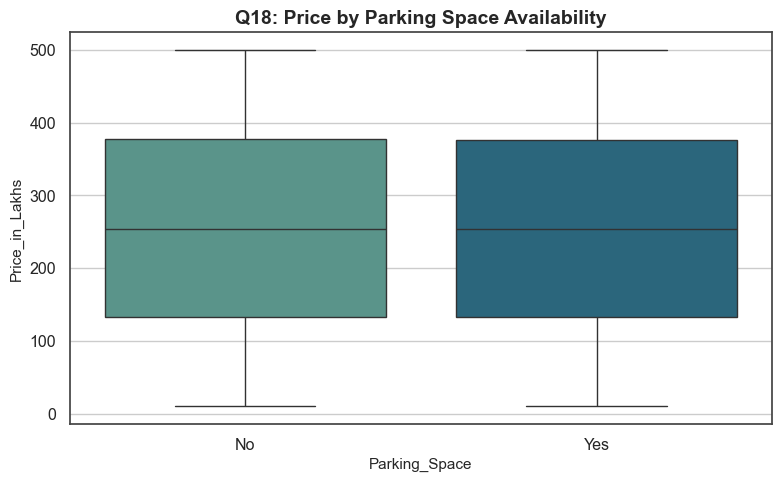

Parking_Space
No     254.429369
Yes    254.745492
Name: Price_in_Lakhs, dtype: float64


In [58]:
# Q18: Does parking space affect price?

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Parking_Space', y='Price_in_Lakhs', hue='Parking_Space', palette=PALETTE, legend=False)
plt.title("Q18: Price by Parking Space Availability")
plt.tight_layout()
plt.show()
print(df.groupby('Parking_Space')['Price_in_Lakhs'].mean())

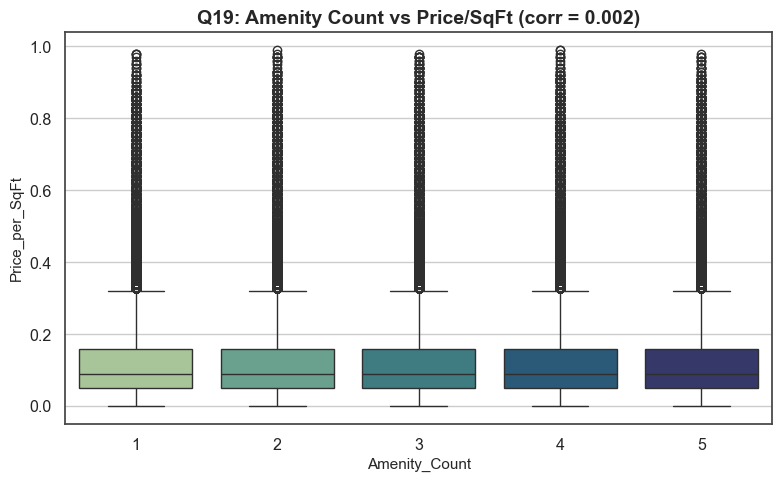

In [59]:
# Q19: Amenities vs price per sqft

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Amenity_Count', y='Price_per_SqFt', hue='Amenity_Count', palette=PALETTE, legend=False)
c19 = df['Amenity_Count'].corr(df['Price_per_SqFt'])
plt.title(f"Q19: Amenity Count vs Price/SqFt (corr = {c19:.3f})")
plt.tight_layout()
plt.show()

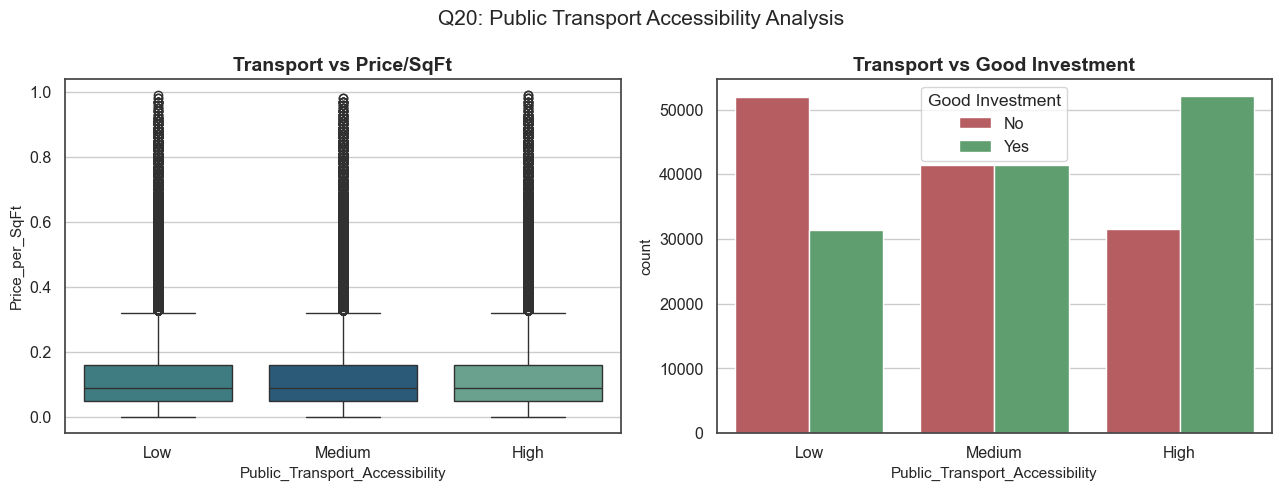

In [60]:
# Q20: Public transport accessibility vs price per sqft / investment potential

fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(data=df, x='Public_Transport_Accessibility', y='Price_per_SqFt',
            order=['Low','Medium','High'], hue='Public_Transport_Accessibility', palette=PALETTE, ax=axes[0], legend=False)
axes[0].set_title("Transport vs Price/SqFt")
sns.countplot(data=df, x='Public_Transport_Accessibility', hue='Good_Investment',
              order=['Low','Medium','High'], palette=['#C44E52','#55A868'], ax=axes[1])
axes[1].set_title("Transport vs Good Investment")
axes[1].legend(title="Good Investment", labels=['No','Yes'])
plt.suptitle("Q20: Public Transport Accessibility Analysis")
plt.tight_layout()
plt.show()

# Step 3: Model Development

In [61]:
# Preprocessing for modeling (train/test split + scaling)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('india_housing_prices_cleaned.csv')

cat_cols = ['State','City','Locality','Property_Type','Furnished_Status',
            'Facing','Owner_Type','Availability_Status']
label_encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df[c + '_enc'] = le.fit_transform(df[c])
    label_encoders[c] = le  # save for Streamlit form later

# IMPORTANT: Appreciation_Score and Implied_CAGR are excluded — they are the exact
# formulas used to derive both targets, so including them would be direct leakage.
feature_cols = ['BHK','Size_in_SqFt','Price_in_Lakhs','Price_per_SqFt','Year_Built','Floor_No',
                 'Total_Floors','Age_of_Property','Nearby_Schools','Nearby_Hospitals','Amenity_Count',
                 'Transport_Score','Security_Score'] + [c + '_enc' for c in cat_cols]

X = df[feature_cols]
y_clf = df['Good_Investment']
y_reg = df['Future_Price_5Y']

In [62]:
# Classification split + scaling

Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

scaler_clf = StandardScaler()
Xtr_c_scaled = scaler_clf.fit_transform(Xtr_c)
Xte_c_scaled = scaler_clf.transform(Xte_c)

In [ ]:
# Regression split + scaling

Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
Xtr_r_scaled = scaler_reg.fit_transform(Xtr_r)
Xte_r_scaled = scaler_reg.transform(Xte_r)

Logistic Regression: Acc=0.811 | F1=0.811 | ROC-AUC=0.905


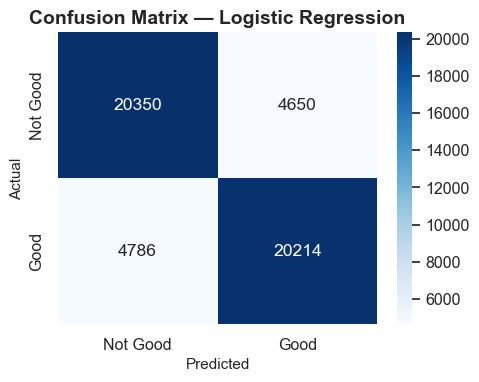

Decision Tree: Acc=0.832 | F1=0.835 | ROC-AUC=0.919


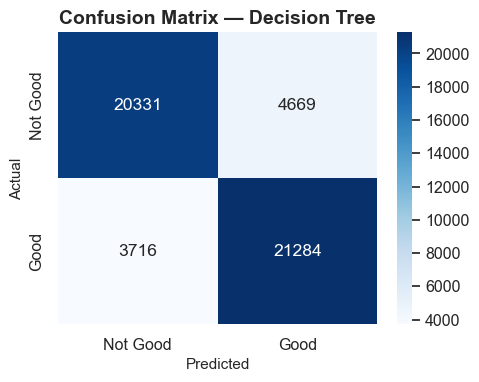

Random Forest: Acc=0.879 | F1=0.878 | ROC-AUC=0.957


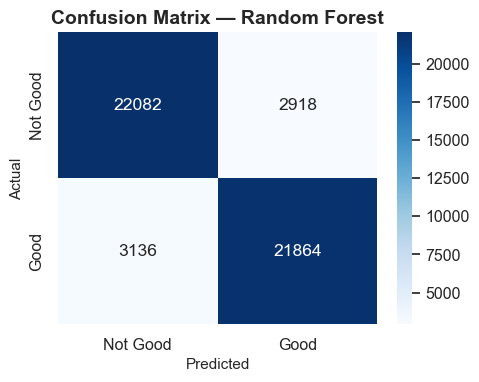

Gradient Boosting: Acc=0.915 | F1=0.915 | ROC-AUC=0.976


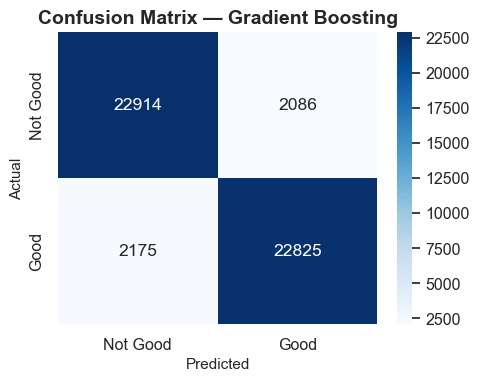

XGBoost: Acc=0.983 | F1=0.983 | ROC-AUC=0.999


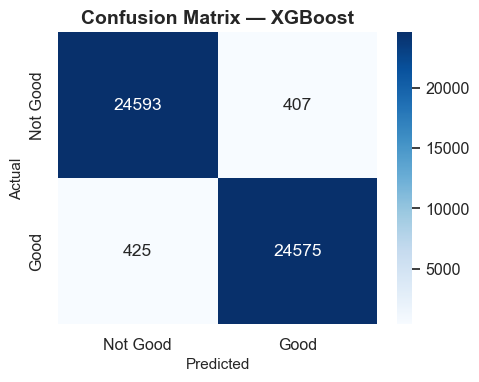

                 Model  Accuracy  Precision   Recall  F1 Score   ROC AUC
4              XGBoost   0.98336   0.983708  0.98300  0.983354  0.999111
3    Gradient Boosting   0.91478   0.916262  0.91300  0.914628  0.976453
2        Random Forest   0.87892   0.882253  0.87456  0.878390  0.956718
1        Decision Tree   0.83230   0.820098  0.85136  0.835437  0.918689
0  Logistic Regression   0.81128   0.812983  0.80856  0.810765  0.905116


In [67]:
# Classification models — training + evaluation (Accuracy, Precision, Recall, F1, ROC AUC, Confusion Matrix)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, random_state=42, eval_metric='logloss'),
}

clf_results = []
for name, model in classifiers.items():
    model.fit(Xtr_c_scaled, ytr_c)
    pred = model.predict(Xte_c_scaled)
    proba = model.predict_proba(Xte_c_scaled)[:, 1]

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(yte_c, pred),
        'Precision': precision_score(yte_c, pred),
        'Recall': recall_score(yte_c, pred),
        'F1 Score': f1_score(yte_c, pred),
        'ROC AUC': roc_auc_score(yte_c, proba),
    }
    clf_results.append(metrics)
    print(f"{name}: Acc={metrics['Accuracy']:.3f} | F1={metrics['F1 Score']:.3f} | ROC-AUC={metrics['ROC AUC']:.3f}")

    cm = confusion_matrix(yte_c, pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Good','Good'], yticklabels=['Not Good','Good'])
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

clf_results_df = pd.DataFrame(clf_results).sort_values('ROC AUC', ascending=False)
print(clf_results_df)

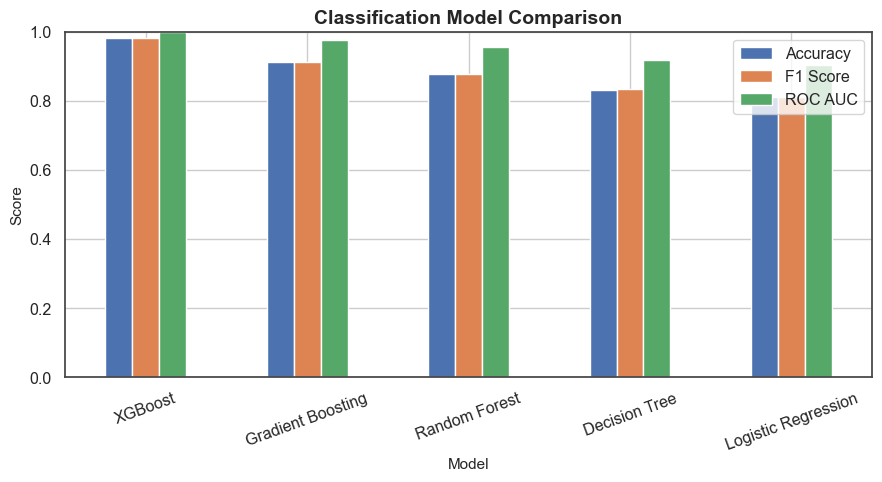

In [68]:
# Classification comparison chart

plt.figure(figsize=(9,5))
clf_results_df.set_index('Model')[['Accuracy','F1 Score','ROC AUC']].plot(kind='bar', ax=plt.gca())
plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Linear Regression: RMSE=7.86 | MAE=6.04 | R2=0.998


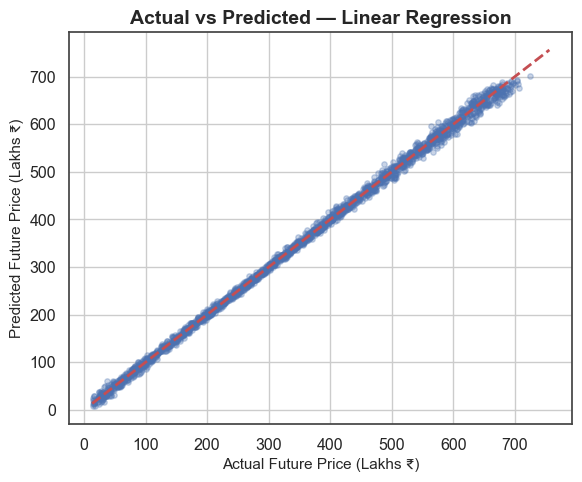

Decision Tree: RMSE=8.76 | MAE=6.26 | R2=0.998


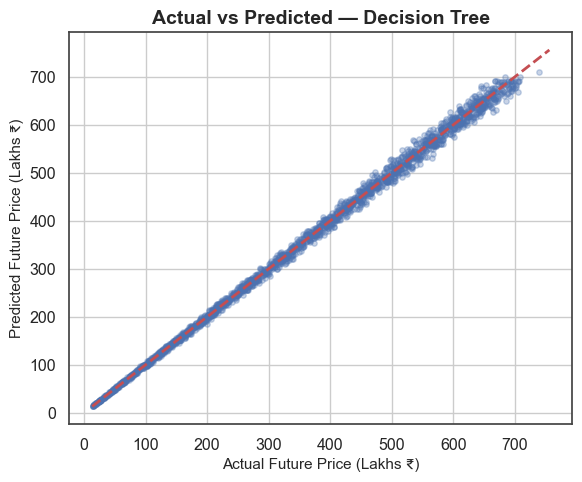

Random Forest: RMSE=6.69 | MAE=4.82 | R2=0.999


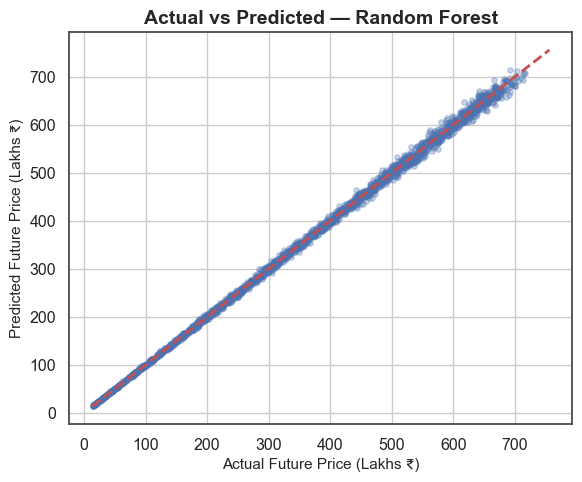

Gradient Boosting: RMSE=4.61 | MAE=3.36 | R2=0.999


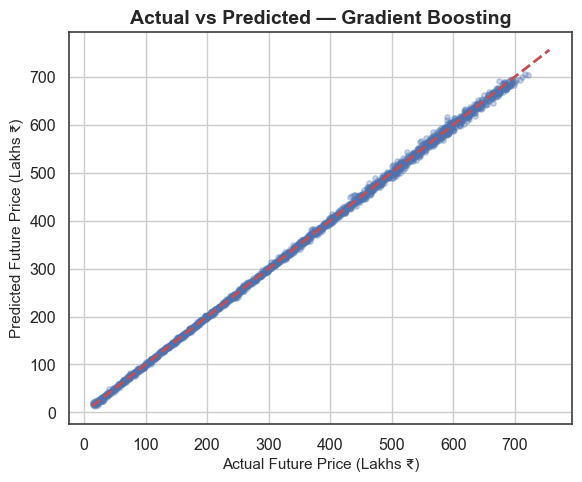

XGBoost: RMSE=1.61 | MAE=1.23 | R2=1.000


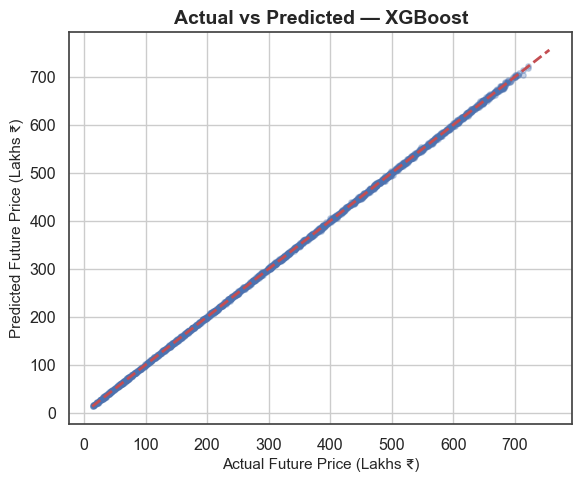

               Model      RMSE       MAE  R2 Score
4            XGBoost  1.606011  1.233526  0.999932
3  Gradient Boosting  4.611022  3.362932  0.999440
2      Random Forest  6.693105  4.818303  0.998819
0  Linear Regression  7.859870  6.039103  0.998371
1      Decision Tree  8.757305  6.263448  0.997978


In [69]:
# Regression models — training + evaluation (RMSE, MAE, R²)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

regressors = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, max_depth=3, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, max_depth=6, random_state=42),
}

reg_results = []
for name, model in regressors.items():
    model.fit(Xtr_r_scaled, ytr_r)
    pred = model.predict(Xte_r_scaled)

    rmse = mean_squared_error(yte_r, pred) ** 0.5
    metrics = {
        'Model': name,
        'RMSE': rmse,
        'MAE': mean_absolute_error(yte_r, pred),
        'R2 Score': r2_score(yte_r, pred),
    }
    reg_results.append(metrics)
    print(f"{name}: RMSE={rmse:.2f} | MAE={metrics['MAE']:.2f} | R2={metrics['R2 Score']:.3f}")

    plt.figure(figsize=(6,5))
    sample_idx = np.random.choice(len(yte_r), min(2000, len(yte_r)), replace=False)
    plt.scatter(yte_r.values[sample_idx], pred[sample_idx], alpha=0.3, s=15)
    plt.plot([yte_r.min(), yte_r.max()], [yte_r.min(), yte_r.max()], 'r--', lw=2)
    plt.xlabel("Actual Future Price (Lakhs ₹)")
    plt.ylabel("Predicted Future Price (Lakhs ₹)")
    plt.title(f"Actual vs Predicted — {name}")
    plt.tight_layout()
    plt.show()

reg_results_df = pd.DataFrame(reg_results).sort_values('R2 Score', ascending=False)
print(reg_results_df)

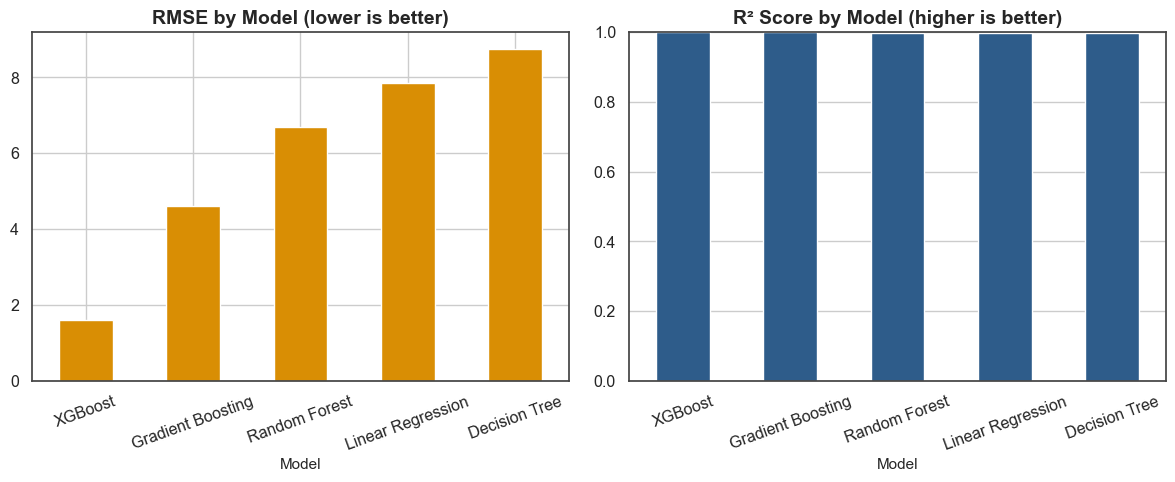

In [70]:
# Regression comparison chart

fig, axes = plt.subplots(1, 2, figsize=(12,5))
reg_results_df.set_index('Model')['RMSE'].plot(kind='bar', ax=axes[0], color='#D98E04')
axes[0].set_title("RMSE by Model (lower is better)")
axes[0].tick_params(axis='x', rotation=20)

reg_results_df.set_index('Model')['R2 Score'].plot(kind='bar', ax=axes[1], color='#2E5C8A')
axes[1].set_title("R² Score by Model (higher is better)")
axes[1].set_ylim(0,1)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

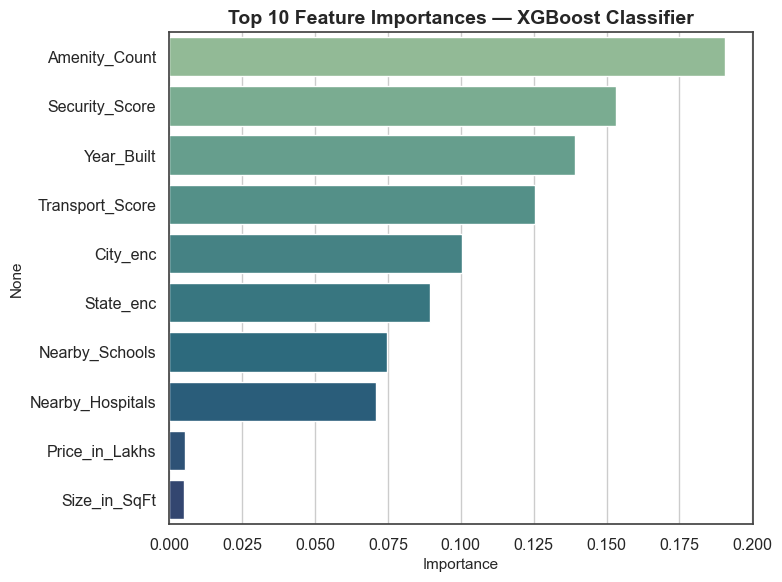

In [71]:
# Feature importance (tree-based models — useful for Step 5's "feature importance" display)

plt.figure(figsize=(8,6))
importances = pd.Series(classifiers['XGBoost'].feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='crest', legend=False)
plt.title("Top 10 Feature Importances — XGBoost Classifier")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Step 4: MLflow Integration

In [74]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.models import infer_signature

mlflow.set_tracking_uri("sqlite:///mlflow.db")  # creates mlflow.db in your working directory

In [75]:
# Classification experiment — train, track, and log all 5 models

mlflow.set_experiment("Real_Estate_Good_Investment_Classification")

best_clf_score = -1
best_clf_run_id = None
best_clf_name = None

for name, model in classifiers.items():
    with mlflow.start_run(run_name=name):
        model.fit(Xtr_c_scaled, ytr_c)
        pred = model.predict(Xte_c_scaled)
        proba = model.predict_proba(Xte_c_scaled)[:, 1]

        acc = accuracy_score(yte_c, pred)
        prec = precision_score(yte_c, pred)
        rec = recall_score(yte_c, pred)
        f1 = f1_score(yte_c, pred)
        auc = roc_auc_score(yte_c, proba)

        # Log params & metrics
        mlflow.log_param("model_type", name)
        mlflow.log_params(model.get_params())
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", auc)

        # Log model artifact
        signature = infer_signature(Xtr_c_scaled, model.predict(Xtr_c_scaled))
        if name == 'XGBoost':
            mlflow.xgboost.log_model(model, name="model", signature=signature)
        else:
            mlflow.sklearn.log_model(model, name="model", signature=signature)

        print(f"{name}: acc={acc:.3f} f1={f1:.3f} auc={auc:.3f}")

        if auc > best_clf_score:
            best_clf_score = auc
            best_clf_run_id = mlflow.active_run().info.run_id
            best_clf_name = name

print(f"\nBest classifier: {best_clf_name} (ROC-AUC={best_clf_score:.3f})")

2026/07/21 04:00:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/21 04:00:37 INFO mlflow.store.db.utils: Updating database tables
2026/07/21 04:00:38 INFO mlflow.tracking.fluent: Experiment with name 'Real_Estate_Good_Investment_Classification' does not exist. Creating a new experiment.
2026/07/21 04:00:38 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message

Logistic Regression: acc=0.811 f1=0.811 auc=0.905
Decision Tree: acc=0.832 f1=0.835 auc=0.919
Random Forest: acc=0.879 f1=0.878 auc=0.957
Gradient Boosting: acc=0.915 f1=0.915 auc=0.976
XGBoost: acc=0.983 f1=0.983 auc=0.999

Best classifier: XGBoost (ROC-AUC=0.999)


In [76]:
# Register the best classification model

model_uri = f"runs:/{best_clf_run_id}/model"
registered_clf = mlflow.register_model(model_uri, "GoodInvestmentClassifier")
print(f"Registered: {registered_clf.name} v{registered_clf.version}")

Successfully registered model 'GoodInvestmentClassifier'.
2026/07/21 04:02:57 WARNING mlflow.tracking._model_registry.fluent: Run with id fe5f36fcafe64841a6b1310178ac6fee has no artifacts at artifact path 'model', registering model based on models:/m-efae4abf632f4378ada685bc3f8611f7 instead


Registered: GoodInvestmentClassifier v1


Created version '1' of model 'GoodInvestmentClassifier'.


In [77]:
# Regression experiment — train, track, and log all 5 models

mlflow.set_experiment("Real_Estate_Future_Price_Regression")

best_reg_score = -1e9
best_reg_run_id = None
best_reg_name = None

for name, model in regressors.items():
    with mlflow.start_run(run_name=name):
        model.fit(Xtr_r_scaled, ytr_r)
        pred = model.predict(Xte_r_scaled)

        rmse = mean_squared_error(yte_r, pred) ** 0.5
        mae = mean_absolute_error(yte_r, pred)
        r2 = r2_score(yte_r, pred)

        mlflow.log_param("model_type", name)
        mlflow.log_params(model.get_params())
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2_score", r2)

        signature = infer_signature(Xtr_r_scaled, model.predict(Xtr_r_scaled))
        if name == 'XGBoost':
            mlflow.xgboost.log_model(model, name="model", signature=signature)
        else:
            mlflow.sklearn.log_model(model, name="model", signature=signature)

        print(f"{name}: rmse={rmse:.2f} mae={mae:.2f} r2={r2:.3f}")

        if r2 > best_reg_score:
            best_reg_score = r2
            best_reg_run_id = mlflow.active_run().info.run_id
            best_reg_name = name

print(f"\nBest regressor: {best_reg_name} (R2={best_reg_score:.3f})")

2026/07/21 04:03:21 INFO mlflow.tracking.fluent: Experiment with name 'Real_Estate_Future_Price_Regression' does not exist. Creating a new experiment.


Linear Regression: rmse=7.86 mae=6.04 r2=0.998
Decision Tree: rmse=8.76 mae=6.26 r2=0.998
Random Forest: rmse=6.69 mae=4.82 r2=0.999
Gradient Boosting: rmse=4.61 mae=3.36 r2=0.999
XGBoost: rmse=1.61 mae=1.23 r2=1.000

Best regressor: XGBoost (R2=1.000)


In [78]:
# Register the best regression model

model_uri = f"runs:/{best_reg_run_id}/model"
registered_reg = mlflow.register_model(model_uri, "FuturePriceRegressor")
print(f"Registered: {registered_reg.name} v{registered_reg.version}")

Successfully registered model 'FuturePriceRegressor'.
2026/07/21 04:06:10 WARNING mlflow.tracking._model_registry.fluent: Run with id 68ab030147ca46efbf91a2a1bee5e298 has no artifacts at artifact path 'model', registering model based on models:/m-6d8fb38f2d344055839a78cdef29648c instead


Registered: FuturePriceRegressor v1


Created version '1' of model 'FuturePriceRegressor'.


In [79]:
# Promote the registered models to "Production" alias (for Streamlit to load reliably)

from mlflow import MlflowClient

client = MlflowClient()

client.set_registered_model_alias("GoodInvestmentClassifier", "production", registered_clf.version)
client.set_registered_model_alias("FuturePriceRegressor", "production", registered_reg.version)

print("Both models promoted to 'production' alias.")

Both models promoted to 'production' alias.


In [80]:
# Launch the MLflow UI to view runs, compare metrics, and browse the registry

mlflow ui --backend-store-uri sqlite:///mlflow.db

SyntaxError: invalid syntax (1960319918.py, line 3)